# LSST SN Ia Simulation Pipeline

Forward-model SN Ia light curves with the Rubin/LSST 10-year baseline cadence using `lightcurvelynx`.

**Survey**: LSST baseline v5.0.1 OpSim (`baseline_v5.0.1_10yrs.db`)  
**Model**: SALT3 via `SncosmoWrapperModel`  
**Filters**: u, g, r, i, z, y  
**Redshift**: volumetric rate (Frohmaier et al. 2019), z = 0.01–1.2  
**Parameters**: Gaussian priors for x1 and c (no pzflow, no host galaxy)

## 1. Imports

## 0. Environment Setup

Set `LIGHTCURVELYNX_DATA_DIR` **before** importing lightcurvelynx — the download path is resolved at import time.  
Downloaded files (OpSim DB, passbands) will be stored in `./data/` inside this project directory.

In [1]:
import os
from pathlib import Path

# Store downloaded data inside this project so it travels with the repo checkout.
# Must be set before any lightcurvelynx imports (path is resolved at import time).
_data_dir = Path().resolve() / "data"
_data_dir.mkdir(exist_ok=True)
os.environ["LIGHTCURVELYNX_DATA_DIR"] = str(_data_dir)
print(f"LIGHTCURVELYNX_DATA_DIR = {_data_dir}")

LIGHTCURVELYNX_DATA_DIR = /Users/mi/Work/lightcurvelynx_sncollab/data


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding

/Users/mi/anaconda3/envs/lightcurvelynx_sncollab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Simulation Configuration

In [3]:
SEED = 1024
RNG  = np.random.default_rng(SEED)

SIM_PARAMS = {
    # Cosmology
    "H0": 73.0,
    "Omega_m": 0.3,
    # Redshift range
    "zmin": 0.01,
    "zmax": 1.2,
    "znbins": 100,
    # Tripp relation coefficients
    "alpha": 0.14,
    "beta": 3.1,
    # SALT3 Gaussian priors (no pzflow, no host galaxy)
    "x1_mean": 0.0,  "x1_sigma": 1.0,
    "c_mean":  0.0,  "c_sigma":  0.1,
    "m_abs_mean": -19.3, "m_abs_sigma": 0.12,
    # Survey
    "filters": ["u", "g", "r", "i", "z", "y"],
    "sky_coverage": 18_000.0,  # LSST WFD footprint in deg²
}

## 3. Load LSST OpSim

The file is downloaded once and cached locally by `OpSim.from_url()`.

In [4]:
OPSIM_URL = (
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/"
    "sims_featureScheduler_runs5.0/baseline/baseline_v5.0.1_10yrs.db"
)
opsim = OpSim.from_url(OPSIM_URL)
print(f"OpSim loaded: {len(opsim):,} observations")
print(f"MJD range: {opsim['time'].min():.1f} – {opsim['time'].max():.1f}")
print(f"Filters:    {sorted(opsim['filter'].unique())}")

OpSim loaded: 2,092,088 observations
MJD range: 60981.0 – 64632.3
Filters:    ['g', 'i', 'r', 'u', 'y', 'z']


## 4. Calculate Number of SNe to Simulate

Integrate the volumetric SN Ia rate over the survey volume and duration:
$$N = \int_{z_{\rm min}}^{z_{\rm max}} r_v(z)\,\frac{dV}{dz}\,\frac{dz}{1+z} \times \Omega \times T_{\rm survey}$$

In [5]:
t_min = float(opsim["time"].min())
t_max = float(opsim["time"].max())

survey_length = (t_max - t_min) / 365.25
print(f"Survey length = {survey_length:.2f} years")

solid_angle = SIM_PARAMS["sky_coverage"] * (np.pi / 180.0) ** 2
print(f"Solid angle   = {solid_angle:.4f} sr  ({SIM_PARAMS['sky_coverage']:,.0f} deg²)")

nsntotal, _ = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    znbins=1,
    solid_angle=solid_angle,
    vol_rate_function=snia_volumetric_rates,
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
nsn = int(nsntotal[0] * survey_length)
nsn = 100
print(f"Expected SNe Ia = {nsn:,}")

Survey length = 10.00 years
Solid angle   = 5.4831 sr  (18,000 deg²)
Expected SNe Ia = 100


## 5. Load LSST Passbands

In [6]:
passbands = PassbandGroup.from_preset("LSST", filters=SIM_PARAMS["filters"])
print(passbands)

PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## 6. Redshift Distribution (Volumetric Rate)

Use the Frohmaier et al. (2019) volumetric rate $r_v(z) = r_0\,(1+z)^\alpha$ to compute the
expected number of SNe Ia per redshift bin, then build an interpolated PDF for sampling.

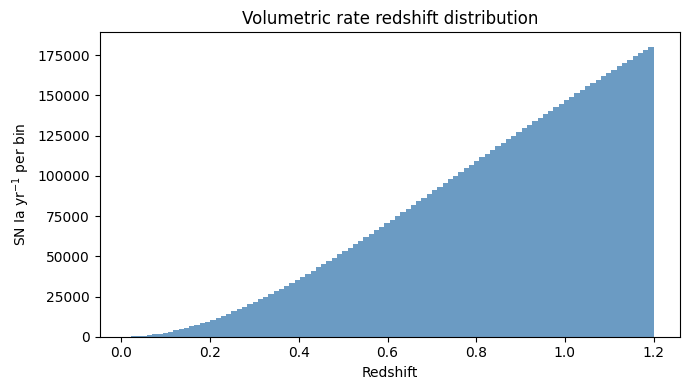

In [7]:
nsn_per_bin, z_mean = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    SIM_PARAMS["znbins"],
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
zpdf = interp1d(z_mean, nsn_per_bin, bounds_error=False, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
dz = (SIM_PARAMS["zmax"] - SIM_PARAMS["zmin"]) / SIM_PARAMS["znbins"]
ax.bar(z_mean, nsn_per_bin, width=dz, color="steelblue", alpha=0.8)
ax.set(xlabel="Redshift", ylabel="SN Ia yr$^{-1}$ per bin",
       title="Volumetric rate redshift distribution")
plt.tight_layout()
plt.show()

## 7. Build SN Ia Source Model

Parameter graph:
- **RA, Dec** — uniformly sampled from the observed LSST footprint (`ObsTableUniformRADECSampler`)
- **redshift** — drawn from the volumetric rate PDF (`SamplePDF`)
- **x1** — Gaussian($\mu=0$, $\sigma=1$)
- **c** — Gaussian($\mu=0$, $\sigma=0.1$)
- **M_abs** — Gaussian($\mu=-19.3$, $\sigma=0.12$)
- **distmod** — computed from redshift via `DistModFromRedshift`
- **x0** — computed via the Tripp relation through `X0FromDistMod`

In [8]:
# RA/Dec: uniform over the opsim footprint (rejection sampling)
radec = ObsTableUniformRADECSampler(opsim, node_label="radec")

# Redshift from volumetric rate PDF
z_func = SamplePDF(zpdf, node_label="redshift")

# Gaussian SALT3 parameter priors
x1_func    = NumpyRandomFunc("normal", loc=SIM_PARAMS["x1_mean"],    scale=SIM_PARAMS["x1_sigma"])
c_func     = NumpyRandomFunc("normal", loc=SIM_PARAMS["c_mean"],     scale=SIM_PARAMS["c_sigma"])
m_abs_func = NumpyRandomFunc("normal", loc=SIM_PARAMS["m_abs_mean"], scale=SIM_PARAMS["m_abs_sigma"])

# x0 via Tripp relation
distmod_func = DistModFromRedshift(
    z_func, H0=SIM_PARAMS["H0"], Omega_m=SIM_PARAMS["Omega_m"]
)
x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=SIM_PARAMS["alpha"],
    beta=SIM_PARAMS["beta"],
    m_abs=m_abs_func,
    node_label="x0_func",
)

# Extrapolation settings
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()

# Assemble the SALT3 source (no host galaxy)
source = SncosmoWrapperModel(
    "salt3",
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=radec.ra,
    dec=radec.dec,
    redshift=z_func,
    node_label="source",
    time_extrapolation=(time_extrap_before,time_extrap_after),
    wave_extrapolation=(wave_extrap_before,wave_extrap_after),  
)
print("Source model built successfully.")

Source model built successfully.


## 8. Run Simulation

In [9]:
opsim.columns

Index(['observationId', 'ra', 'dec', 'time', 'flush_by_mjd', 'exptime', 'band',
       'filter', 'rotation', 'rotSkyPos_desired', 'nexposure', 'airmass',
       'seeingFwhm500', 'seeing', 'seeingFwhmGeom', 'skybrightness', 'night',
       'slewTime', 'visitTime', 'slewDistance', 'maglim', 'altitude',
       'azimuth', 'paraAngle', 'pseudoParaAngle', 'cloud', 'moonAlt', 'sunAlt',
       'scheduler_note', 'target_name', 'target_id', 'observationStartLST',
       'rotTelPos', 'rotTelPos_backup', 'moonAz', 'sunAz', 'sunRA', 'sunDec',
       'moonRA', 'moonDec', 'moonDistance', 'solarElong', 'moonPhase',
       'cummTelAz', 'observation_reason', 'science_program',
       'cloud_extinction', 'zp'],
      dtype='object')

In [10]:
param_cols = [
    "source.t0",
    "source.x0",
    "source.x1",
    "source.c",
    "source.redshift",
    "source.ra",
    "source.dec",
    "x0_func.distmod",
]
obstable_save_cols = ["zp"]

results = simulate_lightcurves(
    model=source,
    num_samples=nsn,
    obstable=opsim,
    passbands=passbands,
    param_cols=param_cols,
    obstable_save_cols=obstable_save_cols,
    rng=RNG,
    # num_jobs=8,
    # batch_size=5000,
)
print(f"Simulated {len(results):,} SNe Ia")
results.head()

Simulating: 100%|██████████| 100/100 [00:00<00:00, 190.28obj/s]


Simulated 100 SNe Ia


id          ra        dec  nobs            t0         z  \
0   0  116.086309  -3.811344   849  62038.370887  0.313946   
1   1   45.213502 -82.444046   126  64055.619968  1.047565   
2   2  133.312253   3.446732   838  63723.331274  0.817532   
3   3  318.617876   3.705047   419  62129.388597  0.713630   
4   4  123.197017  27.197186   212  61366.102699  0.743005   

                                              params     source_t0  source_x0  \
0  {'radec.ra': 116.08630888196515, 'radec.dec': ...  62038.370887   0.000032   
1  {'radec.ra': 45.2135021309461, 'radec.dec': -8...  64055.619968   0.000002   
2  {'radec.ra': 133.3122530933845, 'radec.dec': 3...  63723.331274   0.000003   
3  {'radec.ra': 318.6178764025334, 'radec.dec': 3...  62129.388597   0.000005   
4  {'radec.ra': 123.19701680961936, 'radec.dec': ...  61366.102699   0.000003   

   source_x1  source_c  source_redshift   source_ra  source_dec  \
0  -0.303710  0.060172         0.313946  116.086309   -3.811344   
1  -1.480048  0.031460         1.047565   45.213502  -82.444046   
2   0.618886  0.146124         0.817532  133.312253    3.446732   
3  -1.092745  0.006739         0.713630  318.617876    3.705047   
4   0.663817  0.163211         0.743005  123.197017   27.197186   

   x0_func_distmod                                         lightcurve  
0        40.978360  [{mjd: 61001.339218, filter: 'i', flux: -234.1...  
1        44.133892  [{mjd: 60981.024388, filter: 'r', flux: -80.44...  
2        43.469354  [{mjd: 61012.352427, filter: 'y', flux: -910.2...  
3        43.107018  [{mjd: 61191.349025, filter: 'y', flux: 1434.3...  
4        43.214347  [{mjd: 61049.194007, filter: 'r', flux: 123.46...

## 9. Diagnostics

Quick sanity checks on the simulated population.

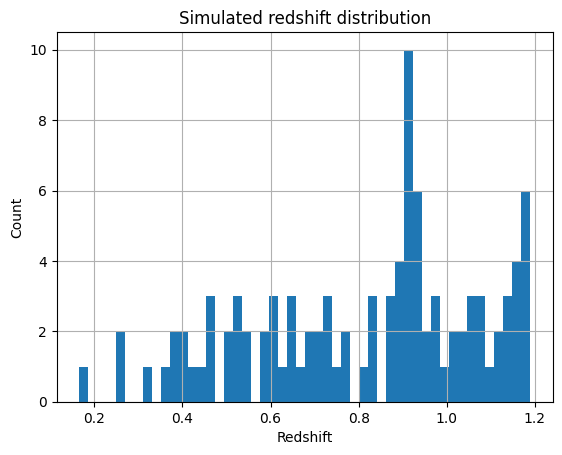

In [11]:
# redshift distribution of simulated SNe
fig, ax = plt.subplots()
results["source_redshift"].hist(bins=50, ax=ax)
ax.set(xlabel="Redshift", ylabel="Count", title="Simulated redshift distribution")
plt.show()

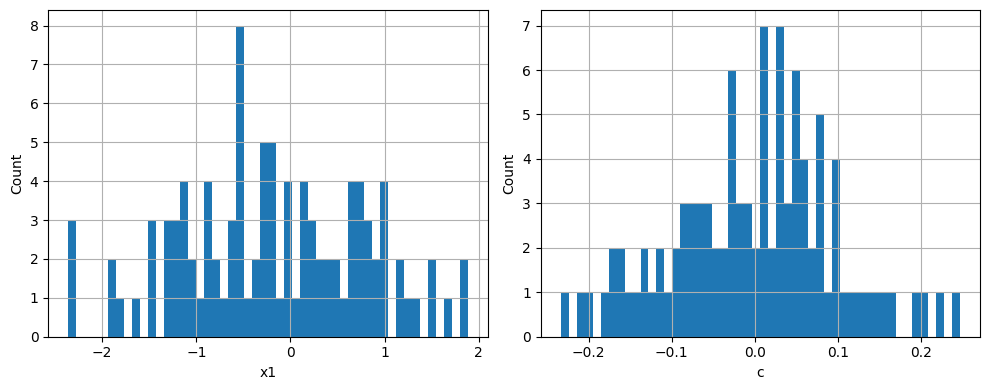

In [12]:
# x1 and c distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results["source_x1"].hist(bins=50, ax=axes[0])
axes[0].set(xlabel="x1", ylabel="Count")
results["source_c"].hist(bins=50, ax=axes[1])
axes[1].set(xlabel="c", ylabel="Count")
plt.tight_layout()
plt.show()

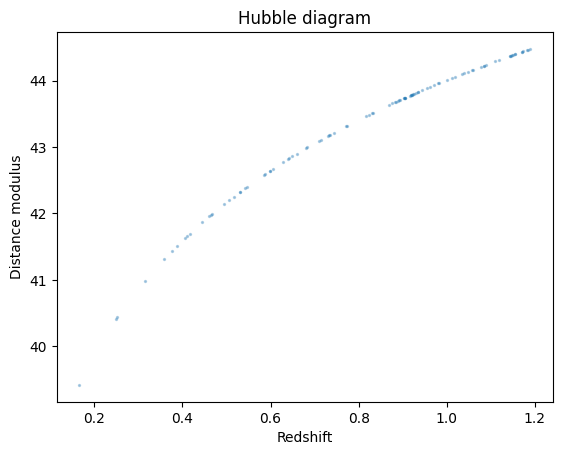

In [13]:
# distmod vs redshift
fig, ax = plt.subplots()
ax.scatter(results["source_redshift"], results["x0_func_distmod"], s=2, alpha=0.3)
ax.set(xlabel="Redshift", ylabel="Distance modulus", title="Hubble diagram")
plt.show()

              mjd filter        flux     fluxerr  flux_perfect  survey_idx  \
0    61045.279824      i -532.201389  318.103284      0.000000           0   
1    61045.307635      z -408.408943  487.575233      0.000000           0   
..            ...    ...         ...         ...           ...         ...   
116  64437.145658      i   54.643437  359.747145      6.918578           0   
117  64437.169226      z  750.577447  687.554522      6.918578           0   

     obs_idx  is_saturated        zp  
0      25242         False  0.671009  
1      25304         False  0.955708  
..       ...           ...       ...  
116  1982322         False  0.690634  
117  1982374         False  0.982269  

[118 rows x 9 columns]


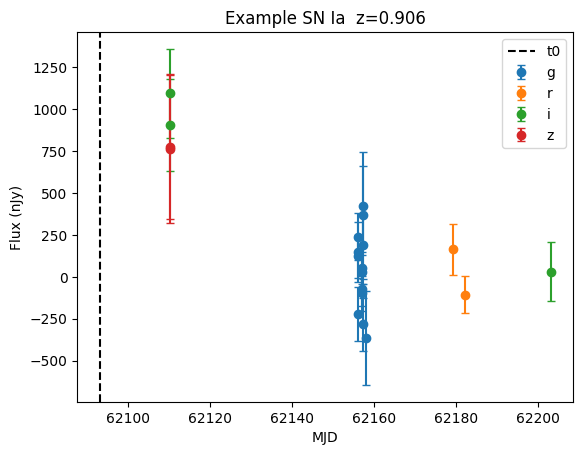

In [14]:
# example light curve for a single SN
sn = results.iloc[np.random.choice(len(results))]
lc = sn["lightcurve"]
print(lc)
for band in SIM_PARAMS["filters"]:
    mask = lc["filter"] == band
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) > -20  # only show points within 20 days before t0
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) < 100   # only show points within 20 days after t0
    if mask.any():
        plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                     fmt="o", label=band, capsize=3)
plt.axvline(sn["source_t0"], ls="--", color="k", label="t0")
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f'Example SN Ia  z={sn["source_redshift"]:.3f}')
plt.show()

In [15]:
lc.columns

Index(['mjd', 'filter', 'flux', 'fluxerr', 'flux_perfect', 'survey_idx',
       'obs_idx', 'is_saturated', 'zp'],
      dtype='object')

## 10. Save Results

In [16]:
# save results
output_path = "output/lsst_snia_results.parquet"
output_path = Path(output_path)
output_path.parent.mkdir(exist_ok=True)
results.to_parquet(output_path)
print(f"Saved to {output_path}")

Saved to output/lsst_snia_results.parquet
